# Titanic data science project
https://www.kaggle.com/c/titanic


In [409]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [410]:
from os import path

train_path = path.join('datasets', 'titanic', 'train.csv')
test_path = path.join('datasets', 'titanic', 'test.csv')

In [411]:
train_data = pd.read_csv(train_path)
display(train_data.sample(10))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
70,71,0,2,"Jenkin, Mr. Stephen Curnow",male,32.0,0,0,C.A. 33111,10.5000,NaN,S
645,646,1,1,"Harper, Mr. Henry Sleeper",male,48.0,1,0,PC 17572,76.7292,D33,C
515,516,0,1,"Walker, Mr. William Anderson",male,47.0,0,0,36967,34.0208,D46,S
580,581,1,2,"Christy, Miss. Julie Rachel",female,25.0,1,1,237789,30.0000,NaN,S
226,227,1,2,"Mellors, Mr. William John",male,19.0,0,0,SW/PP 751,10.5000,NaN,S
366,367,1,1,"Warren, Mrs. Frank Manley (Anna Sophia Atkinson)",female,60.0,1,0,110813,75.2500,D37,C
325,326,1,1,"Young, Miss. Marie Grice",female,36.0,0,0,PC 17760,135.6333,C32,C
618,619,1,2,"Becker, Miss. Marion Louise",female,4.0,2,1,230136,39.0000,F4,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
530,531,1,2,"Quick, Miss. Phyllis May",female,2.0,1,1,26360,26.0000,NaN,S


In [412]:
test_data = pd.read_csv(test_path)
display(test_data.head())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [413]:
print(f"Train data shape: {train_data.shape}, Test data shape: {test_data.shape}")
display(train_data.describe(include='all'))
print(train_data.info())

Train data shape: (891, 12), Test data shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


<Axes: xlabel='Embarked', ylabel='Survived'>

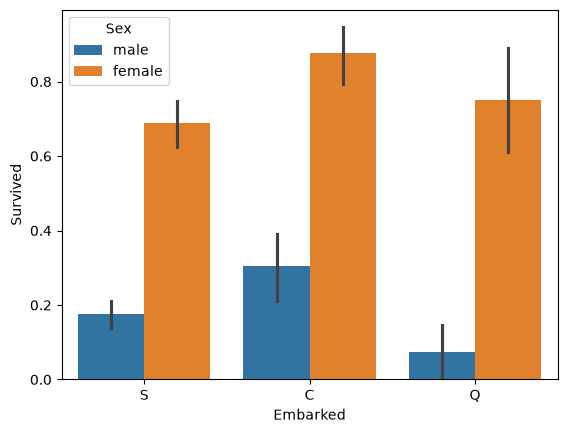

In [414]:
sns.barplot(x='Embarked', y='Survived', hue='Sex', data=train_data)

<Axes: xlabel='Pclass', ylabel='Survived'>

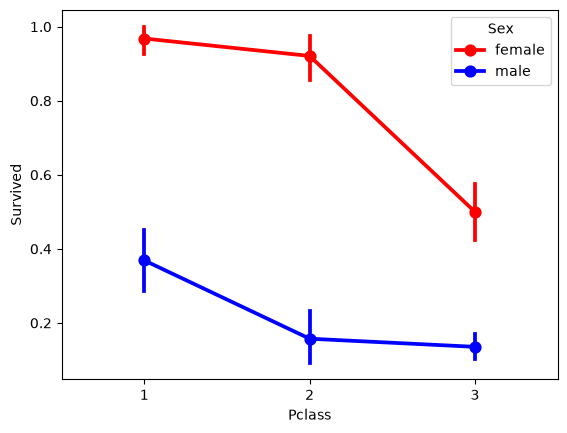

In [415]:
sns.pointplot(x='Pclass', y='Survived', hue='Sex', palette={'male': 'blue', 'female': 'red'}, data=train_data)

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

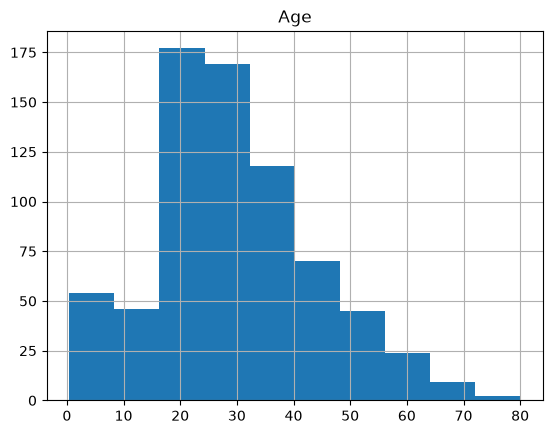

In [416]:
train_data.hist(column='Age')

In [417]:
# Function to categorize age into different age groups
def cat_age(data):
  data['Age'] = data['Age'].fillna(-0.5)
  bins = [-1, 0, 5, 12, 18, 25, 35, 60, 120]
  labels = ['Missing', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Senior']
  data['Age'] = pd.cut(data['Age'], bins=bins, labels=labels)
  return

In [418]:
cat_age(train_data)
cat_age(test_data)

train_data['Age'].sample(10)

778        Missing
538        Missing
167          Adult
45         Missing
256        Missing
423    Young Adult
229        Missing
888        Missing
480          Child
563        Missing
Name: Age, dtype: category
Categories (8, str): ['Missing' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'Young Adult' < 'Adult' < 'Senior']

<Axes: xlabel='Cabin', ylabel='count'>

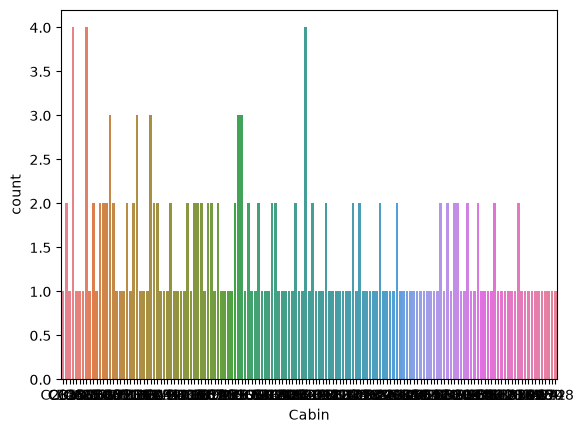

In [419]:
sns.countplot(x='Cabin', data=train_data, hue='Cabin', legend=False)

In [420]:
train_data['Cabin'].sample(10)

444    NaN
459    NaN
143    NaN
651    NaN
694    NaN
262    E67
448    NaN
839    C47
543    NaN
531    NaN
Name: Cabin, dtype: str

In [421]:
# Function to extract the deck information from the cabin column
def extract_cabin(data):
  data['Cabin'] = data['Cabin'].fillna('N')
  # Extract the first letter of the cabin to represent the deck
  data['Cabin'] = data['Cabin'].apply(lambda x: x[0])
  return

In [422]:
extract_cabin(train_data)
extract_cabin(test_data)

train_data['Cabin'].sample(10)

321    N
162    N
571    C
518    N
345    F
515    D
410    N
541    N
37     N
714    N
Name: Cabin, dtype: str

In [423]:
train_data['Fare'].sample(10)

626     12.3500
817     37.0042
519      7.8958
76       7.8958
258    512.3292
334    133.6500
818      6.4500
621     52.5542
311    262.3750
225      9.3500
Name: Fare, dtype: float64

In [424]:
# Function to categorize the fare into quantile-based bins
def cat_fare(data):
  data['Fare'] = data['Fare'].fillna(0.0)
  # Categorize the fare into bins
  cat_names = ['1st', '2nd', '3rd', '4th', '5th']
  data['Fare'] = pd.qcut(data['Fare'], q=5, labels=cat_names)
  return

In [425]:
cat_fare(train_data)
cat_fare(test_data)

train_data['Fare'].sample(10)

615    5th
500    2nd
838    5th
19     1st
251    2nd
481    1st
817    4th
650    2nd
112    2nd
823    3rd
Name: Fare, dtype: category
Categories (5, str): ['1st' < '2nd' < '3rd' < '4th' < '5th']

In [426]:
train_data['Name'].sample(10)

801        Collyer, Mrs. Harvey (Charlotte Annie Tate)
48                                 Samaan, Mr. Youssef
591    Stephenson, Mrs. Walter Bertram (Martha Eustis)
359                  Mockler, Miss. Helen Mary "Ellie"
201                                Sage, Mr. Frederick
606                                  Karaic, Mr. Milan
162                         Bengtsson, Mr. John Viktor
28                       O'Dwyer, Miss. Ellen "Nellie"
856         Wick, Mrs. George Dennick (Mary Hitchcock)
304                  Williams, Mr. Howard Hugh "Harry"
Name: Name, dtype: str

In [427]:
def extract_title(data):
  title = data['Name'].str.split().str[1]
  data['Title'] = title.mask(~title.str.endswith('.', na=True), 'Unknown')
  return

In [428]:
extract_title(train_data)
extract_title(test_data)

train_data['Title'].sample(100)
# Group the data by the 'Title' column and count the number of occurrences for each title
train_data.groupby('Title').size()

Title
Capt.          1
Col.           2
Don.           1
Dr.            7
Jonkheer.      1
Major.         2
Master.       40
Miss.        179
Mlle.          2
Mme.           1
Mr.          502
Mrs.         121
Ms.            1
Rev.           6
Unknown       25
dtype: int64

In [429]:
train_data.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
70,71,0,2,"Jenkin, Mr. Stephen Curnow",male,Young Adult,0,0,C.A. 33111,2nd,N,S,Mr.
667,668,0,3,"Rommetvedt, Mr. Knud Paust",male,Missing,0,0,312993,1st,N,S,Mr.
513,514,1,1,"Rothschild, Mrs. Martin (Elizabeth L. Barrett)",female,Adult,1,0,PC 17603,5th,N,C,Mrs.
672,673,0,2,"Mitchell, Mr. Henry Michael",male,Senior,0,0,C.A. 24580,2nd,N,S,Mr.
241,242,1,3,"Murphy, Miss. Katherine ""Kate""",female,Missing,1,0,367230,3rd,N,Q,Miss.
800,801,0,2,"Ponesell, Mr. Martin",male,Young Adult,0,0,250647,3rd,N,S,Mr.
457,458,1,1,"Kenyon, Mrs. Frederick R (Marion)",female,Missing,1,0,17464,5th,D,S,Mrs.
51,52,0,3,"Nosworthy, Mr. Richard Cater",male,Student,0,0,A/4. 39886,1st,N,S,Mr.
627,628,1,1,"Longley, Miss. Gretchen Fiske",female,Student,0,0,13502,5th,D,S,Miss.
886,887,0,2,"Montvila, Rev. Juozas",male,Young Adult,0,0,211536,3rd,N,S,Rev.


In [430]:
def drop_columns(data, columns):
  data.drop(columns, axis=1, inplace=True)

In [431]:
columns_to_drop = ['Name', 'Ticket', 'Embarked']
drop_columns(train_data, columns_to_drop)
drop_columns(test_data, columns_to_drop)

train_data.sample(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Title
230,231,1,1,female,Young Adult,1,0,5th,C,Mrs.
293,294,0,3,female,Student,0,0,2nd,N,Miss.
844,845,0,3,male,Teenager,0,0,2nd,N,Mr.
804,805,1,3,male,Young Adult,0,0,1st,N,Mr.
454,455,0,3,male,Missing,0,0,2nd,N,Mr.
798,799,0,3,male,Young Adult,0,0,1st,N,Unknown
270,271,0,1,male,Missing,0,0,4th,N,Mr.
51,52,0,3,male,Student,0,0,1st,N,Mr.
779,780,1,1,female,Adult,0,1,5th,B,Mrs.
104,105,0,3,male,Adult,2,0,2nd,N,Mr.


<Axes: xlabel='Age', ylabel='Survived'>

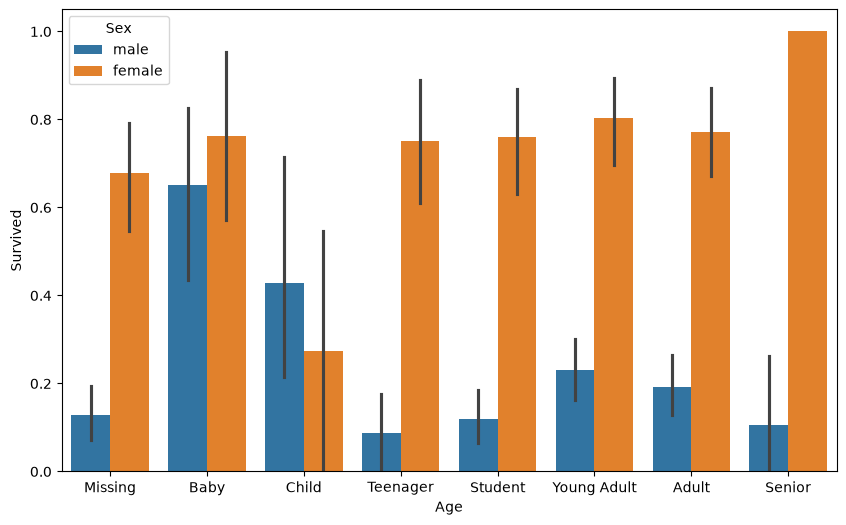

In [432]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Age', y='Survived', hue='Sex', data=train_data, ax=ax)

<Axes: xlabel='Fare', ylabel='Survived'>

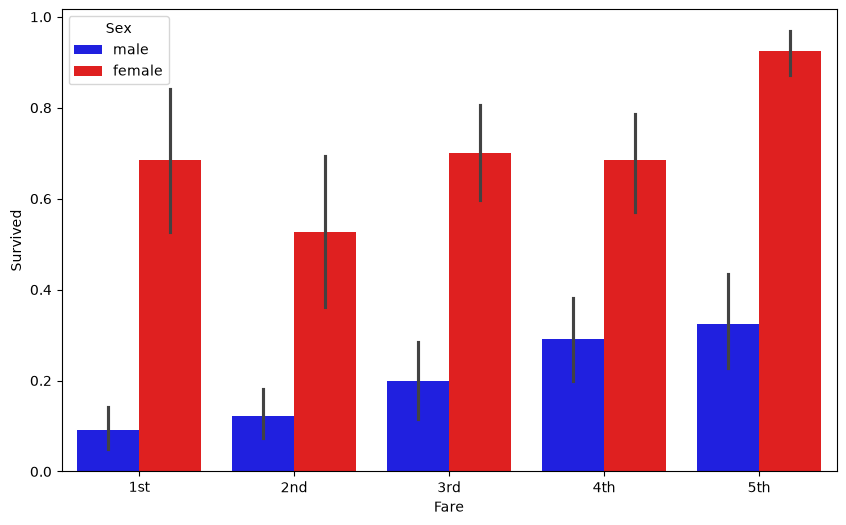

In [433]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Fare', y='Survived', hue='Sex', palette={'male': 'blue', 'female': 'red'}, data=train_data, ax=ax)

In [434]:
from sklearn import preprocessing

In [435]:
# Function to encode categorical features using LabelEncoder from sklearn
def encode_features(df_train, df_test, features):
  df_combined = pd.concat([df_train[features], df_test[features]], axis=0)
  for feature in features:
    # Initialize the LabelEncoder for the current feature
    le = preprocessing.LabelEncoder()
    le = le.fit(df_combined[feature])
    # Transform the training and test data using the fitted LabelEncoder
    df_train[feature] = le.transform(df_train[feature])
    df_test[feature] = le.transform(df_test[feature])

In [436]:
features = ['Sex', 'Age', 'Fare', 'Cabin', 'Title']
encode_features(train_data, test_data, features)
train_data.sample(5)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Title
151,152,1,1,0,5,1,0,4,2,11
115,116,0,3,1,5,0,0,1,7,10
453,454,1,1,1,0,1,0,4,2,10
295,296,0,1,1,3,0,0,3,7,10
18,19,0,3,0,7,1,0,2,7,14


In [437]:
from sklearn.model_selection import train_test_split

In [438]:
# Separate features and target variable from the training data
X= train_data.drop('Survived', axis=1) # Features (independent variables)
Y= train_data['Survived'] # Independent variable (target)

# Split the data into training and validation sets
validation_size = 0.15
# Set the random seed for reproducibility
seed = np.random.randint(1000)
# Perform the train-test split. Return 4 datasets: X_train, X_val, Y_train, Y_val
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=validation_size, random_state=seed)

display(X_train.sample(5), Y_train.sample(5))
display(X_val.sample(5), Y_val.sample(5))

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Title
709,710,3,1,3,1,1,2,7,6
581,582,1,0,0,1,1,4,2,11
379,380,3,1,5,0,0,0,7,10
816,817,3,0,5,0,0,1,7,7
353,354,3,1,5,1,0,2,7,10


730    1
636    0
231    0
794    0
858    1
Name: Survived, dtype: int64

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Title
169,170,3,1,7,0,0,4,7,10
123,124,2,0,7,0,0,2,4,7
258,259,1,0,7,0,0,4,7,7
733,734,2,1,5,0,0,2,7,10
160,161,3,1,0,0,1,2,7,10


734    0
230    1
813    0
327    1
871    1
Name: Survived, dtype: int64

In [439]:
from sklearn.tree import DecisionTreeClassifier

In [440]:
# Initialize and train the Decision Tree model
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

In [441]:
from sklearn.metrics import accuracy_score
# Make predictions on the validation set and evaluate accuracy
predictions = model.predict(X_val)
print(predictions)
# Print the accuracy of the model on the validation set
# The score represents the proportion of correctly predicted samples out of the total samples
print(accuracy_score(Y_val, predictions))

[1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 1 1 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 1 1 1 1
 0 1 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 1 1 0 0 0 0 0 0
 0 1 1 1 1 1 0 0 0 1 1 1 0 1 1 0 1 1 0 0 0 0 0 0 1 1 0 0 1 1 1 0 0 0 1 1 1
 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0]
0.753731343283582


[[63 17]
 [16 38]]


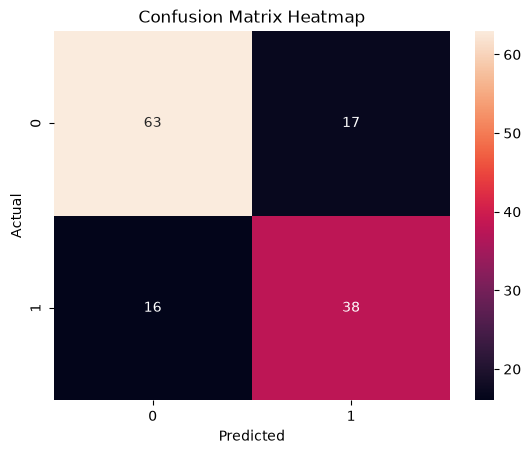

In [442]:
from sklearn.metrics import confusion_matrix
# Print the confusion matrix for the validation set predictions
# The confusion matrix shows the number of correct and incorrect predictions for each class
# 0,0 represents the number of true negatives (correctly predicted 0s)
# 0,1 represents the number of false positives (incorrectly predicted 1s)
# 1,0 represents the number of false negatives (incorrectly predicted 0s)
# 1,1 represents the number of true positives (correctly predicted 1s)
print(confusion_matrix(Y_val, predictions))
sns.heatmap(confusion_matrix(Y_val, predictions), annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [443]:
from sklearn.metrics import classification_report
# Print the classification report for the validation set predictions
# The classification report includes precision, recall, f1-score, and support for each class
# Precision is the ratio of correctly predicted positive observations to the total predicted positives
# Recall is the ratio of correctly predicted positive observations to all observations in the actual class
# F1-score is the weighted average of precision and recall
# Support is the number of actual occurrences of the class in the dataset
print(classification_report(Y_val, predictions))

              precision    recall  f1-score   support

           0       0.80      0.79      0.79        80
           1       0.69      0.70      0.70        54

    accuracy                           0.75       134
   macro avg       0.74      0.75      0.74       134
weighted avg       0.75      0.75      0.75       134



In [ ]:
# Remove PassengerId from features, validate if prediction improves
X= train_data.drop(['Survived', 'PassengerId'], axis=1) # Features (independent variables)
Y= train_data['Survived'] # Independent variable (target)

validation_size = 0.15
seed = np.random.randint(1000)
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=validation_size, random_state=seed)

model = DecisionTreeClassifier()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_val)
accuracy = accuracy_score(Y_val, Y_pred)
print("Validation Accuracy:", accuracy)
print(classification_report(Y_val, Y_pred))

Validation Accuracy: 0.8507462686567164
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        86
           1       0.82      0.75      0.78        48

    accuracy                           0.85       134
   macro avg       0.84      0.83      0.83       134
weighted avg       0.85      0.85      0.85       134



In [ ]:
# Perform multiple iterations of training and validation to find the most accurate Decision Tree model
n_iter = 1000
result = []
most_accurate = (DecisionTreeClassifier(), 0)

for i in range(n_iter):
  seed = np.random.randint(1000)
  X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=validation_size, random_state=seed)
  model = DecisionTreeClassifier()
  model.fit(X_train, Y_train)
  Y_pred = model.predict(X_val)
  accuracy = accuracy_score(Y_val, Y_pred)
  result.append(accuracy)
  if accuracy > most_accurate[1]:
    most_accurate = (model, accuracy)
print("Mean Validation Accuracy over", n_iter, "iterations:", np.mean(result))
print("Most Accurate Validation Accuracy over", n_iter, "iterations:", most_accurate[1])


Mean Validation Accuracy over 1000 iterations: 0.791955223880597
Most Accurate Validation Accuracy over 1000 iterations: 0.8880597014925373


In [ ]:
# Use